# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification.

## TO-DO LIST

- We need to add Data augmentation in the pipeline!
- Data preprocessing should be functional! (Now scattered across cells) minor rework
- Better Model checkpoints + save the best model (if val_loss < best_loss)
- Configuration management???
- Explicit data split function (split_subjects/cv) and explicit evaluation function... now data leakeage is possible (inline slicing...)
- Experiment runs tracking

In [1]:
import importlib.util

RUNNING_ON_GOOGLE = False

if RUNNING_ON_GOOGLE:
  from google.colab import drive
  drive.mount('/content/drive')
  # This path MUST BE CHANGED IN A USER BASIS
  %cd '/content/drive/MyDrive/ACADEMIA/ML4HD_LABS/PROJECT/src'

  # Check if 'mne' is already installed to avoid re-installation!! (SAVES 10 PRECIOUS SECONDS)
  if importlib.util.find_spec('mne') is None:
    #%pip install mne
    14
  if importlib.util.find_spec('loguru') is None:
    #%pip install loguru

    # This is the sample file that is going to be used initially to extract general shape features from EEG
    sample_file = 3
    # for unban420
    sample_file = 5
else:
  sample_file = 0

In [ ]:
import importlib
import warnings
import scipy.io
import os
import sys
import gc


# Add the current directory to the Python path to detect the utils folder
sys.path.append('.')
import utils.utils as u
import utils.preprocessing as p
import utils.models as m

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


from tqdm.auto import tqdm
import numpy as np
import mne
import polars as pl
import numpy as np
from loguru import logger
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP
from itertools import groupby
from scipy.signal import butter, filtfilt


mne.set_log_level('WARNING')
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)



def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


config = {
    ## GENERAL
    "seed": 42,
    ## DATA SPLITTING AND AUGMENTATION
    # this hyperparameter controls how many files are ingested (in case we are using a lower-end commodity pc for example, 16gb of ram is not enough)
    "input_file_limit": 5,
    # This would produce a split of size 80/10/10 with augmentation x3
    "train_data_proportion": 0.8,
    "val_test_data_ratio": 0.5,
    "augment_factor": 3,
    ## Preprocessing
    "sampling_rate": 200,
    "window_size": 2.0,
    ## Deep Learning General Hyperparameters
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,


}
set_seed(config["seed"])


2026-01-12 21:15:02.005484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/walterjtv/.pyenv/versions/ml4hd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018.

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [3]:
# Get the file names from directory of the files of the experiment
experiment = "CLA"
files=u.get_file_names("../data", experiment=experiment)
files = files[:config["input_file_limit"]] 
logger.info("The following {} files where found: {}", experiment, files)

2026-01-12 21:15:04.560 | INFO     | __main__:<module>:5 - The following CLA files where found: ['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [4]:
def load_mat_file(FILE):
    """Load a .mat file and return its contents."""
    skip=False
    mat_data = scipy.io.loadmat(FILE)
    # The file includes metadata coming from python that we don't need.
    # We will focus on the 'o' key which contains the EEG data and information about the experiment.
    data = mat_data['o'][0, 0]
    sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
    eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
    channel_names = [
        str(ch[0]).strip("[]' ")
        for ch in data["chnames"]
    ]
    info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
    if 'X5' in channel_names:
        info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
    else:
        logger.warning("Channel X5 not found, skipping file.")
        logger.warning(channel_names)
        skip=True
        return None, None, skip
    montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
    info.set_montage(montage)
    raw = mne.io.RawArray(eeg_data, info)
    return raw, data, skip

## 0.1. Syncronization data exploration
First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [5]:
raw, data, _ = load_mat_file(files[sample_file])
labels = np.array(data['marker'])
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        logger.info("Marker {}: Length {}", marker, length)
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    logger.success("\nMinimum length of a non-zero marker series: {}", min(non_zero_lengths))



2026-01-12 21:15:05.629 | INFO     | __main__:<module>:9 - Marker [3]: Length 203
2026-01-12 21:15:05.631 | INFO     | __main__:<module>:9 - Marker [3]: Length 203
2026-01-12 21:15:05.632 | INFO     | __main__:<module>:9 - Marker [1]: Length 203
2026-01-12 21:15:05.633 | INFO     | __main__:<module>:9 - Marker [1]: Length 204
2026-01-12 21:15:05.633 | INFO     | __main__:<module>:9 - Marker [2]: Length 203
2026-01-12 21:15:05.638 | SUCCESS  | __main__:<module>:12 - 
Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

2026-01-12 21:15:05.657 | INFO     | __main__:<module>:9 - Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
2026-01-12 21:15:05.659 | INFO     | __main__:<module>:11 - Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
2026-01-12 21:15:05.660 | INFO     | __main__:<module>:13 - Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
2026-01-12 21:15:05.661 | INFO     | __main__:<module>:16 - Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
2026-01-12 21:15:05.695 | INFO     | __main__:<module>:29 - Spike onsets in the plotted window: [100399 101084 101634]


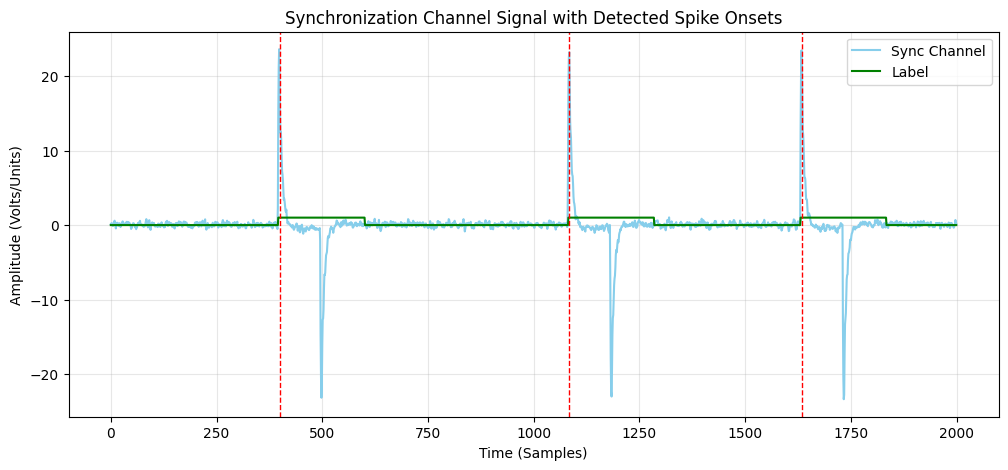

In [6]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
logger.info(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
logger.info(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
logger.info(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
logger.info(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
logger.info(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

## 1. PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

Quoting [Altaheri23]: "Pre-processing is generally performed in three main
steps: channel selection, signal frequency filtering, and
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment)
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")\n
 A high-pass cutoff has been passed.

2. Robust Referencing
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance.

3. Bad Channel Interpolation
THIS CAN BE DONE

(4. Rereferencing or undo interpolation)


In [7]:
def PREP(raw):
    # --- High-pass cutoff ---
    raw.filter(l_freq=1.0, h_freq=None)
    # --- Laplace Reference (Surface Laplacian) ---
    # In MNE, this is often done by calculating the Surface Laplacian.
    raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))
    return raw_laplace

Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [8]:
def create_epochs(raw_laplace, data):

    markers_diff = np.diff(data["marker"].squeeze())
    all_transition_indices = np.where(markers_diff != 0)[0] + 1
    all_values = data["marker"].squeeze()[all_transition_indices]
    valid_mask = (all_values != 0) & (all_values < 90)
    event_samples_filtered = all_transition_indices[valid_mask]
    event_values_filtered = all_values[valid_mask]

    # Reconstruct the events array
    event_count = len(event_samples_filtered)
    events = np.column_stack([
        event_samples_filtered,
        np.zeros(event_count, dtype=int),
        event_values_filtered
    ]).astype(int)

    epochs_laplace = mne.Epochs(
        raw=raw_laplace,
        events=events,
        tmin=0,
        tmax=0.85,
        baseline=None,
        preload=True
    )
    return epochs_laplace

In [9]:
all_X = []
all_y = []

for file in files:
    raw, data, skip = load_mat_file(file)
    if skip:
        continue
    raw_laplace = PREP(raw)
    epochs_laplace = create_epochs(raw_laplace, data)

    # Get the data and labels
    X_tmp = epochs_laplace.get_data()  # Shape: (n_epochs, n_channels, n_times)
    y_tmp = epochs_laplace.events[:, 2] # Shape: (n_epochs,)

    logger.info(f"\n File: {file}")
    logger.info(f"  X shape: {X_tmp.shape}")
    logger.info(f"  y shape: {y_tmp.shape}")

    all_X.append(X_tmp)
    all_y.append(y_tmp)


# Combine everything into one big array
X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

logger.info(f"Final X shape: {X.shape}") # (Total_epochs, n_channels, n_times)
logger.info(f"Final y shape: {y.shape}") # (Total_epochs,)

2026-01-12 21:15:07.274 | INFO     | __main__:<module>:15 - 
 File: ../data/CLA-SubjectA-160108-3St-LRHand.mat
2026-01-12 21:15:07.275 | INFO     | __main__:<module>:16 -   X shape: (960, 21, 171)
2026-01-12 21:15:07.275 | INFO     | __main__:<module>:17 -   y shape: (960,)
2026-01-12 21:15:08.499 | INFO     | __main__:<module>:15 - 
 File: ../data/CLA-SubjectB-151019-3St-LRHand.mat
2026-01-12 21:15:08.500 | INFO     | __main__:<module>:16 -   X shape: (959, 21, 171)
2026-01-12 21:15:08.501 | INFO     | __main__:<module>:17 -   y shape: (959,)
2026-01-12 21:15:09.538 | INFO     | __main__:<module>:15 - 
 File: ../data/CLA-SubjectB-151215-3St-LRHand.mat
2026-01-12 21:15:09.539 | INFO     | __main__:<module>:16 -   X shape: (960, 21, 171)
2026-01-12 21:15:09.540 | INFO     | __main__:<module>:17 -   y shape: (960,)
2026-01-12 21:15:10.586 | INFO     | __main__:<module>:15 - 
 File: ../data/CLA-SubjectD-151125-3St-LRHand.mat
2026-01-12 21:15:10.589 | INFO     | __main__:<module>:16 -   X 

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no.
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [10]:
def augment_eeg_data(X, y, multiplier=3):
    if multiplier <= 1:
       return X, y
    n_trials, n_chans, n_samples = X.shape

    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=config["sampling_rate"])
    noise_candidates = filtfilt(b, a, X, axis=-1)

    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates

    X_aug_list = [X] # Start with original data
    y_aug_list = [y]

    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [11]:
unique_labels = np.unique(y)
N = len(unique_labels)
logger.info(f"Number of classes: {N}, Classes: {unique_labels}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1-config["train_data_proportion"]), random_state=config["seed"], stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(config["val_test_data_ratio"]), random_state=config["seed"], stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=config["augment_factor"]) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
logger.info(class_weights)
logger.info("Shape of each train/val/test split is {} {} {}", X_train.shape, X_val.shape, X_test.shape)


2026-01-12 21:15:10.994 | INFO     | __main__:<module>:3 - Number of classes: 3, Classes: [1 2 3]
2026-01-12 21:15:11.617 | INFO     | __main__:<module>:17 - {0: np.float64(1.0086750788643533), 1: np.float64(0.9984387197501952), 2: np.float64(0.9930124223602484)}
2026-01-12 21:15:11.618 | INFO     | __main__:<module>:18 - Shape of each train/val/test split is (9207, 21, 171) (384, 21, 171) (384, 21, 171)


## 2. FEATURE EXTRACTION and DATA PREPARATION
As summarized in [Altaheri23], EEG signals can be approched in 4 different ways:

1. Extracting features
2. Using spectral images
3. Directly using the raw preprocessed data
4. Using topological maps

For **1. Extracting features** we will follow the two main suggested approaches in [Altaheri23]: "Luo et al. utilized FBCSP to extract spatial-frequency sequential time slices from MI-EEG signals and classified them using long short-term memory (LSTM) and gated
recurrent unit (GRU) models. The proposed method achieved good results for both recurrent models. In, the authors also used the FBCSP approach to extract spatial features from MI data and fed them into a CNN model as a 2D matrix."

Our approach is not exactly the same to the one found on the papers cited but it is inspired by them. It will be explained why and how later. The two papers are:

T. Luo and F. Chao, “Exploring spatial-frequency-sequential
relationships for motor imagery classification with recurrent neural
network,” BMC Bioinformatics, vol. 19, no. 1, p. 344, 2018.

https://www.researchgate.net/publication/327967384_Exploring_spatial-frequency-sequential_relationships_for_motor_imagery_classification_with_recurrent_neural_network

B. E. Olivas-Padilla and M. I. Chacon-Murguia, “Classification of
multiple motor imagery using deep convolutional neural networks
and spatial filters,” Appl. Soft Comput., vol. 75, pp. 461–472, 2019.

https://www.sciencedirect.com/science/article/pii/S156849461830663X?via%3Dihub

For **3. Directly using the raw preprocessed data** we will follow the two papers suggested by the teachers in the in the project presentation: the already referenced [Zhang21] and

[Lawhern18] V. J. Lawhern, A. J. Solon, N. R. Waytowich, S. M. Gordon, C. P. Hung, and B. J. Lance,
EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces, Journal of
neural engineering, vol. 15, no. 5, p. 056013, 2018.

https://www.researchgate.net/publication/310953136_EEGNet_a_compact_convolutional_neural_network_for_EEG-based_brain-computer_interfaces

TODO: 2 or 4 or both or something else

In [12]:
def extract_windows(dataset, W, n_steps):
    projected = np.matmul(W, dataset.astype('float32'))
    n_samples = projected.shape[-1]
    win_len = int(n_samples * 0.5)
    starts = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    windows = np.stack([projected[..., s:s+win_len] for s in starts], axis=2)
    log_var = np.log(np.var(windows, axis=-1) + 1e-10)
    return log_var

def process_band_to_matrix(X_train, y_train, X_val, X_test, sfreq):
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(X_train, y_train)
    W = csp.filters_
    train_cnn, train_rnn = extract_windows(X_train, W, 3), extract_windows(X_train, W, 15)
    val_cnn, val_rnn     = extract_windows(X_val, W, 3), extract_windows(X_val, W, 15)
    test_cnn, test_rnn   = extract_windows(X_test, W, 3), extract_windows(X_test, W, 15)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)


In [13]:
if not os.path.exists('X_all_filtered.npy'):
    freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
    #1. Combine all data
    X_all = np.concatenate([X_train, X_val, X_test], axis=0)
    n_bands = len(freq_bands)
    X_all_filtered = np.zeros((n_bands, *X_all.shape), dtype='float32')
    for i, (l, h) in enumerate(tqdm(freq_bands, desc="Global Filtering")):
        # filter_data with copy=False is much faster
        X_all_filtered[i] = mne.filter.filter_data(
            X_all,
            config["sampling_rate"],
            l, h,
            method='fir',
            fir_design='firwin',
            n_jobs=-1,
            copy=False,
            verbose=False
        ).astype('float32')

    # You access them via: X_all_filtered[band_idx, :split_val, :, :]

In [14]:
if not os.path.exists('X_all_filtered.npy'):
    np.save('X_all_filtered.npy', X_all_filtered)

In [15]:
if os.path.exists('X_all_filtered.npy'):
    X_all_filtered = np.load('X_all_filtered.npy').astype('float32')
    split_val = len(X_train)
    split_test = len(X_train) + len(X_val)
    train_bands = X_all_filtered[:, :split_val, :, :].astype('float32')
    test_bands = X_all_filtered[:, split_test:, :, :].astype('float32')
    val_bands = X_all_filtered[:, split_val:split_test, :, :].astype('float32')
    del X_all_filtered
    gc.collect()

In [16]:
results = []
for i in tqdm(range(len(train_bands)), desc="Processing CSP and Windows"):
    res = process_band_to_matrix(
        train_bands[i].astype('float32'),
        y_train,
        val_bands[i].astype('float32'),
        test_bands[i].astype('float32'),
        config["sampling_rate"]
    )
    results.append(res)

# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

Processing CSP and Windows: 100%|██████████| 9/9 [01:04<00:00,  7.13s/it]

CNN Shape: (9207, 189, 3)
RNN Shape: (9207, 15, 189)


In [ ]:
n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [18]:
times = epochs_laplace.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
logger.info(f"C: {C}, T: {T}, N: {N}")
logger.info("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis]
X_test = X_test[:, :, :, np.newaxis]
X_val = X_val[:, :, :, np.newaxis]

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
logger.info("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

logger.info("\n")
logger.info("#####################################################\n")
logger.info(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
logger.info(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
logger.info(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

2026-01-12 21:16:18.286 | INFO     | __main__:<module>:5 - C: 21, T: 171, N: 3
2026-01-12 21:16:18.287 | INFO     | __main__:<module>:6 - #####################################################

2026-01-12 21:16:18.289 | INFO     | __main__:<module>:23 - Label map:
2026-01-12 21:16:18.296 | INFO     | __main__:<module>:31 - 

2026-01-12 21:16:18.298 | INFO     | __main__:<module>:32 - #####################################################

2026-01-12 21:16:18.299 | INFO     | __main__:<module>:33 - X train shape: (9207, 21, 171, 1), X_train_features shape: (9207, 189, 3, 1), y train shape: (9207, 3)
2026-01-12 21:16:18.300 | INFO     | __main__:<module>:34 - X test shape: (384, 21, 171, 1), X_test_features shape: (384, 189, 3, 1), y test shape: (384, 3)
2026-01-12 21:16:18.301 | INFO     | __main__:<module>:35 - X val shape: (384, 21, 171, 1), X_val_features shape: (384, 189, 3, 1), y val shape: (384, 3)


In [19]:
import tensorflow as tf
epsilon = 1e-7

def f1_score_metric(y_true, y_pred):

    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))

    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))

    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)

    return f1_val

### Data Augmentation

TODO!!!!

Neural networks are extremely data hungry machine learning algorithms, specially attention based models for the complex patterns they are able to capture. We will make use of **Tensorflow dataset API** to add transformations, preprocessing, caching, shuffling, prefetching, batching...

There are 5 possible augmentations that can enhance data volume and help improve overall generalization of trained models. Without being destructive to the signal, we can add these generic signal augmentation techniques:

1) Gaussian Noise
2) Temporal Shift
3) Random Crop + Resize
4) Channel Random Dropout  
5) Amplitude Scaling

In [20]:
def gaussian_noise(x, std=0.01):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=std)
    return x + noise

def time_shift(x, max_shift=20):
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=2)  # time axis

def random_crop_resize(x, crop_ratio=0.9):
    T = tf.shape(x)[2]
    crop_len = tf.cast(tf.cast(T, tf.float32) * crop_ratio, tf.int32)
    start = tf.random.uniform([], 0, T - crop_len, dtype=tf.int32)
    cropped = x[:, :, start:start+crop_len, :]
    return tf.image.resize(cropped, size=(x.shape[1], T))

def channel_dropout(x, drop_prob=0.1):
    mask = tf.cast(
        tf.random.uniform([tf.shape(x)[1], 1, 1]) > drop_prob,
        tf.float32,
    )
    return x * mask

def amplitude_scaling(x, scale_range=(0.8, 1.2)):
    scale = tf.random.uniform([], scale_range[0], scale_range[1])
    return x * scale


def eeg_augment(x):
    x = gaussian_noise(x, std=0.01)
    x = amplitude_scaling(x)
    x = time_shift(x, max_shift=15)
    x = random_crop_resize(x, crop_ratio=0.9)
    x = channel_dropout(x, drop_prob=0.1)
    return x

## 3. MODEL TRAINING

In this section we will proceed to train different implementations of neural network architectures to solve this non-trivial task. Given the format of the data shown below, CNN's or RNN's are often employed, however its important to note that due to the multi-channel nature of the data, RNN's alone won't work well.

Given the time-series nature of EEG data CNN's alone won't work to the fullest due to the local receptive field inductive bias, it won't be able to capture the long range dependencies in spite of multi-scale kernels as its commonly used in networks like InceptionV4.

So CNN + RNN has been shown in the literature to be better than the previous two alone, however BiLSTM/ LSTM / GRU... often fall short due to the vanishing gradients, serial training, parameter heavy layers, sensitive to sequence length... So often Attention is coupled with CNN's to overcome all this limitations (Parallelizable, Interpretable...), this gives birth to the **CONFORMER**.

Centralized Training configuration:

###  Simple CNN (4M)

In [21]:
cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
cnn.summary()

2026-01-12 21:16:18.346489: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 189, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 189, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 189, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 189, 3, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 189, 3, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,644,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,664,579 (17.79 MB)

 Trainable params: 4,664,387 (17.79 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = cnn.fit(
    X_train_features_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_cnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_cnn = cnn.predict(X_test_features_cnn)
y_pred_cnn = np.argmax(y_cnn, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_cnn)
f1 = f1_score(y_true_labels, y_pred_cnn, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_cnn)
print(cm)

Epoch 1/3
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - f1_score_metric: 0.4703 - loss: 4.6531

288/288 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - f1_score_metric: 0.5063 - loss: 2.3776 - val_f1_score_metric: 0.3535 - val_loss: 1.0825
Epoch 2/3
266/288 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - f1_score_metric: 0.6505 - loss: 0.8419

KeyboardInterrupt: 

### LSTM Based (90K)

In [ ]:
lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
lstm.summary()

In [ ]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = lstm.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_lstm = lstm.predict(X_test_features_rnn)
y_pred_lstm = np.argmax(y_lstm, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_lstm)
f1 = f1_score(y_true_labels, y_pred_lstm, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_lstm)
print(cm)

### GRU Based (132K)

In [ ]:
gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
gru.summary()

In [ ]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = gru.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_gru = gru.predict(X_test_features_rnn)
y_pred_gru = np.argmax(y_gru, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_gru)
f1 = f1_score(y_true_labels, y_pred_gru, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_gru)
print(cm)

### Shallow ConvNet (36K)

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [ ]:
shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

In [ ]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_shallow = shallow.predict(X_test)
y_pred_shallow = np.argmax(y_shallow, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_shallow)
f1 = f1_score(y_true_labels, y_pred_shallow, average='weighted')
print(f"\nModel Accurºacy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_shallow)
print(cm)

### EEGNet (2018) (1.8K?)

In [ ]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


In [ ]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_eegnet = eegnet.predict(X_test)
y_pred_eegnet = np.argmax(y_eegnet, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_eegnet)
f1 = f1_score(y_true_labels, y_pred_eegnet, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_eegnet)
print(cm)

### Inception V4 (281K)

In [ ]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


In [ ]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_inception = inception.predict(X_test)
y_pred_inception = np.argmax(y_inception, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_inception)
f1 = f1_score(y_true_labels, y_pred_inception, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_inception)
print(cm)


#

### EEGConformer (2022) (332K?)

As previously stated, this is the first CNN + Attention model. However transformers need a higher volume of data to learn the intricate patterns in data, so we will need to perform **data augmentation** in the split and preparation pipeline.

In [ ]:
#This model right here has too may hyperparamters, but these are the ones proposed in the paper
# Looking at the paper the head count does not affect that much but rather the number of
# attention layers!!!! attention is all you need they said but i think i need a break 
eegconformer = m.EEGConformer(
    nb_classes=N,Chans = C, Samples = T,
    num_layers=12,   
)
eegconformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
eegconformer.summary()


In [ ]:
# Callbacks
early_stop_eegconformer = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegconformer = ModelCheckpoint("best_eegconformer.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = eegconformer.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegconformer, early_stop_eegconformer],
    class_weight=class_weights
)

y_eegconformer = eegconformer.predict(X_test)
y_pred_eegconformer = np.argmax(y_eegconformer, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_eegconformer)
f1 = f1_score(y_true_labels, y_pred_eegconformer, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_eegconformer)
print(cm)


### CTNet (2024) (500K)


it achieved 0.64 validation score in the first epoch of this tiny dataset (3 or 5 files i think?)



In [ ]:
#This model right here has too may hyperparamters, but these are the ones proposed in the paper 
ctnet = m.CTNet(
    nb_classes=N, Chans = C, Samples = T,
    num_heads=10, num_layers=10, 
    attn_drop_rate=0.2, cnn_drop_rate=0.33,
    n_filters_time=30,
    pool_size_1=2, pool_size_2=2
)
ctnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
#ctnet.summary()


In [ ]:
# Callbacks
early_stop_ctnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_ctnet = ModelCheckpoint("best_ctnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = ctnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_ctnet, early_stop_ctnet ],
    class_weight=class_weights
)

y_ctnet = ctnet.predict(X_test)
y_pred_ctnet = np.argmax(y_ctnet, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_ctnet)
f1 = f1_score(y_true_labels, y_pred_ctnet, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_ctnet)
print(cm)


### DualAttention - EEGConformer (2026) (Walter, Josu et. al) (k?)

This model is an attempt of improvement over the past conformer based models for EEG (EEGConformer and CTNet) using attention not only temporally but spatially (channels) and using cross-attention for both embedding types. Also uses multi-scale CNN patch tokens to enhance the representation power (being a strict superset) and closely align with the filter-bank theory behind EEG ($\delta, \theta, \alpha, \beta, \gamma... waves $) to avoid these preprocessing steps being fixed and rather make it learnable to the network. Also does some minor architectural improvements in terms of classification head customatization and uses skip connections and positional encodings to improve training stability.

In [23]:
importlib.reload(m)

<module 'utils.models' from '/home/walterjtv/Escritorio/College/Q11/ML4HD-Machine-Learning-for-Human-Data/PROJECT/src/utils/models.py'>

In [26]:
#This model right here has too may hyperparamters, but these are the ones proposed in the paper 
daec = m.DualAttentionEEGConformer(
    nb_classes=N,Chans = C, Samples =T,
    # NOTE1: The embdding size will greatly vary the size of the overall architecture
    emb_size=40, 
    patch_pool_size=3, patch_channel_temp_filter_size=4, pe_droprate=0.1,
    # NOTE2: The number of heads must be small if the embedding size is small 
    time_num_layers=10, time_num_heads=4, time_att_droprate=0.15,
    chan_num_layers=10, chan_num_heads=4, chan_att_droprate=0.15,
    cross_time_num_heads=4, cross_time_att_droprate=0.15,
    cross_chan_num_heads=4, cross_chan_att_droprate=0.15, 
    pool_droprate=0.4,
    classif_hidden_units=(128, 64), classif_droprate_probs=(0.4, 0.3),
)
daec.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-5),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
daec.summary()


Time Tokens After temporal convolution: {} (None, 21, 171, 60)
Channel tokens After CONVOLUTION: {} (None, 21, 86, 60)
Channel tokens After flattening temporal + feature dims: {} (None, 21, 5160)
Channel tokens After DENSE: {} (None, 21, 40)
Time tokens After channel convolution: {} (None, 1, 171, 60)
Time tokens After pooling and dropout: {} (None, 1, 57, 60)
Time tokens After DENSE: {} (None, 57, 40)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 21, 171,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 21, 171,   │         40 │ input_layer_3[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 21, 171,   │        192 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 21, 171,   │        400 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 21, 171,   │      1,024 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 21, 171,   │        500 │ input_layer_3[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         32 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         64 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 171,   │         16 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 21, 171,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 171,   │          0 │ activation[0][0]

 Total params: 1,140,895 (4.35 MB)

 Trainable params: 1,140,535 (4.35 MB)

 Non-trainable params: 360 (1.41 KB)

In [27]:
# Callbacks
early_stop_daec = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_daec = ModelCheckpoint("best_daec.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = daec.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_daec, early_stop_daec],
    class_weight=class_weights
)

y_daec = daec.predict(X_test)
y_pred_daec = np.argmax(y_daec, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true_labels, y_pred_daec)
f1 = f1_score(y_true_labels, y_pred_daec, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_daec)
print(cm)


Epoch 1/100
 38/288 ━━━━━━━━━━━━━━━━━━━━ 1:41 408ms/step - f1_score_metric: 0.3183 - loss: 2.2798

KeyboardInterrupt: 

## 4. Evaluation

In [ ]:
experiments = ['CNN', 'LSTM', 'GRU', 'Shallow CNN', 'Compact CNN',
               'Inception', 'EEGConformer', 'CTNet', 'Dual-Attention-EEGConformer'
            ]
y_true_labels = np.argmax(y_test, axis=1)



# --- Calculate Metrics ---
# Group 1: Feature-based encoding (CSP)
feat_metrics_acc = [
    accuracy_score(y_true_labels, y_pred_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_lstm) * 100,
    accuracy_score(y_true_labels, y_pred_gru) * 100,
    0, 0, 0 # Placeholders for the raw slots
]

# Group 2: Raw-based encoding
raw_metrics_acc = [
    0, 0, 0, # Placeholders for the feature slots
    accuracy_score(y_true_labels, y_pred_shallow) * 100,
    accuracy_score(y_true_labels, y_pred_eegnet) * 100,
    accuracy_score(y_true_labels, y_pred_inception) * 100,
    #accuracy_score(y_true_labels, y_eegconformer) * 100,
    #accuracy_score(y_true_labels, y_ctnet) * 100,
    #accuracy_score(y_true_labels, y_daec) * 100,
]

# (Repeat same logic for F1)
feat_metrics_f1 = [
    f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
    0, 0, 0
]
raw_metrics_f1 = [
    0, 0, 0,
    f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_eegnet, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_eegconformer, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_ctnet, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_daec, average='weighted') * 100,
]

feat_weights = [
    cnn.count_params(),
    lstm.count_params(),
    gru.count_params(),
    0, 0, 0
]
raw_weights = [
    0, 0, 0,
    shallow.count_params(),
    eegnet.count_params(),
    inception.count_params(),
]


# --- Plotting ---
x = np.arange(len(experiments))
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 6))

# Accuracy Plot
ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy: Feature vs Raw')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, rotation=15)
ax1.set_ylim(0, 100)
ax1.legend()

# F1 Plot
ax2.bar(x, feat_metrics_f1, color='skyblue',label='Feature-based (FB-CSP)', edgecolor='navy')
ax2.bar(x, raw_metrics_f1, color='sandybrown',label='Raw Signal-based', edgecolor='saddlebrown')
ax2.set_ylabel('F1-Score (%)')
ax2.set_title('F1-Score: Feature vs Raw')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments, rotation=15)
ax2.set_ylim(0, 100)
ax2.legend()

# Accuracy Plot
feat_indices = [i for i, w in enumerate(feat_weights) if w > 0]
raw_indices  = [i for i, w in enumerate(raw_weights) if w > 0]
ax3.scatter([feat_weights[i] for i in feat_indices],
            [feat_metrics_acc[i] for i in feat_indices],
            label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=100)

ax3.scatter([raw_weights[i] for i in raw_indices],
            [raw_metrics_acc[i] for i in raw_indices],
            label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=100)
for i in feat_indices:
    ax3.annotate(experiments[i],
                 (feat_weights[i], feat_metrics_acc[i]),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha='center', fontsize=9, color='navy', fontweight='bold')
for i in raw_indices:
    ax3.annotate(experiments[i],
                 (raw_weights[i], raw_metrics_acc[i]),
                 textcoords="offset points",
                 xytext=(0, -15),
                 ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xlabel('Number of Parameters')
ax3.set_title('Accuracy / #Params: Feature vs Raw')
ax3.legend()
# F1 Plot
ax4.scatter([feat_weights[i] for i in feat_indices],
            [feat_metrics_f1[i] for i in feat_indices],
            label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=100)

ax4.scatter([raw_weights[i] for i in raw_indices],
            [raw_metrics_f1[i] for i in raw_indices],
            label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=100)
for i in feat_indices:
    ax4.annotate(experiments[i],
                 (feat_weights[i], feat_metrics_f1[i]),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha='center', fontsize=9, color='navy', fontweight='bold')
for i in raw_indices:
    ax4.annotate(experiments[i],
                 (raw_weights[i], raw_metrics_f1[i]),
                 textcoords="offset points",
                 xytext=(0, -15),
                 ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
ax4.set_ylabel('F1-Score (%)')
ax4.set_xlabel('Number of Parameters')
ax4.set_title('F1-Score / #Params: Feature vs Raw')
ax4.legend()
plt.tight_layout()
plt.show()

## 5. Hyperparameter Optimization

In this section, hyperparameter optimization of the neural networks is explored. Although this is typically implemented with simple methods as out of the box 3-fold cross-validation. However our data is composed of multiple subjects and sessions (usally 2 sessions per subject in BCI competition), then training and testing in subject A will give inflated accuracy (subject leakage) and training and testing on session 1 will make temporal leakage.

To avoid leakage we must split taking those 2 concepts into account, but also if we want to tune hyperparameters in addition to only evaluation we need to split the data into train/val/test (70/20/10 for example) an perform 2 cross-validations:
- Inner CV: Hyperparameter Tuning (Val data)
- Outer CV: Evaluation (Test data)

There are 3 strategies we can implement with augmenting levels of complexity: (First one is simple train, test, second allows for evaluation CV, and third one evaluation CV + Hyperparameter optimization CV)

1. **Subject-grouped, session-wise split:**  

   Entire recording sessions for a subject are kept together. Train on one session and test on the other to prevent **temporal/session leakage**.  
    *Example:*  

    | Subject | Train Session | Test Session |
    |---------|---------------|--------------|
    | A       | A1             | A2            |
    | B       | B1             | B2            |
    | C       | C1             | C2            |
    | D       | D1             | D2            |


2. **Leave-One-Subject-Out (LOSO): (Evaluation CV):**
    
    One subject is completely held out for testing, while all other subjects are used for training. This prevents **subject leakage** and provides a realistic estimate of **cross-subject generalization**.  
    *Example:*  

    | Fold | Train Subjects | Test Subject |
    |------------|----------------|--------------|
    | 1          | B, C, D        | A            |
    | 2          | A, C, D        | B            |
    | 3          | A, B, D        | C            |
    | 4          | A, B, C        | D            |


3. **Nested, group-aware cross-validation: (Evaluation CV + HyperparamOPT CV)**
    
    **Outer CV**: evaluate final model on a held-out subject  **Inner CV**: split sessions within training data for hyperparameter tuning  
    *Example:*  

    | Fold | Outer Test Subject | Inner Train Sessions         | Inner Validation Sessions   |
    |------------|-----------------|------------------------------|----------------------------|
    | 1          | A               | B1, C1, D1                  | B2, C2, D2                 |
    | 2          | B               | A1, C1, D1                  | A2, C2, D2                 |
    | 3          | C               | A1, B1, D1                  | A2, B2, D2                 |
    | 4          | D               | A1, B1, C1                  | A2, B2, C2                 |




---
In the case of wanting to use Tree-Parzen or Gaussian Process optimization (Optuna), we could insert it in the Inner CV loop of the nested group aware cross validation, on validation data to prevent test leakeage.

**OBVIOUS NOTE:** Only perform this expensive procedures in promising architectures

In [ ]:
# TODO :)

## 6. ABLATION TEST

In this section similar to other EEG publications, a brief ablation test on this deep learning data pipeline is conducted to compare our architecture to other state-of-the-art approaches. The hyperparameters choices such as attention heads, number of attention layers and the disabling or not of some layers are going to be explored in order to asess their contributions.

The ablation study aims to answer the following research questions (divided into 7 groups (G) or areas of research):

0. **G.A**: Are multiscale embeddings better than single scale (A1) ? Is there a significant difference in the frequency range covered by these multiscale filters? 
1. **G.B**: Are both temporal and channel embeddings necessary, or does one dominate?
2. **G.C**: Does cross-attention fusion provide additional gains over independent processing? Is it better to not use cross-attention at all?
3. **G.D**: What is the optimal pooling strategy for aggregating dual-axis representations?
4. **G.E**: How sensitive is the model to the number of attention layers and heads?
5. **G.F**: Does positional encoding improve performance for EEG signals?
6. **G.G**: How does the embedding dimensionality affect performance? Which is a clear bottleneck size?

# TODO END THIS SECTION


In [ ]:
# hey

### 6.1 ABLATION GROUP A : MultiScale Patch Embeddings Analysis 

This experiment investigates the contribution of multi-scale temporal convolutions for capturing different EEG frequency bands, a key innovation of our architecture over baseline models.

**A.1: Single-Scale vs Multi-Scale Comparison**

 Determine if multi-scale convolutions provide gains over single-scale baselines with matched parameter count.

| Exp ID | Kernel Sizes | Filters per Scale | Total Filters | Coverage |
|--------|-------------|-------------------|---------------|----------|
| A1a | `(25,)` | `(60,)` | 60 | Single-scale (alpha band ~10Hz) |
| A1b | `(64,)` | `(60,)` | 60 | Single-scale (theta band ~4Hz) |
| A1c | `(5, 25, 125)` | `(20, 20, 20)` | 60 | 3-scale (gamma, alpha, delta) |
| A1d | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | 60 | **5-scale balanced (baseline)** |

---

**A.2: Kernel Size Coverage**

Testing if kernel sizes aligned with neurophysiological frequency bands improve performance (Frequency Band Hypothesis, the whole premise under the inductive bias of these complex patch embeddings).

| Exp ID | Kernel Sizes | Filters per Scale | Frequency Coverage |
|--------|-------------|-------------------|-------------------|
| A2a | `(3, 7, 15, 31, 63, 125)` | `(6, 8, 12, 12, 12, 10)` | **Full spectrum** (100Hz → 2Hz) |
| A2b | `(5, 12, 25, 64, 125)` | `(12, 12, 12, 12, 12)` | **Baseline** (missing theta gap) |
| A2c | `(7, 15, 31, 63)` | `(15, 15, 15, 15)` | **Mid-range only** (beta-alpha-theta) |
| A2d | `(3, 7, 15)` | `(20, 20, 20)` | **High-frequency only** (gamma-beta) |
| A2e | `(31, 63, 125)` | `(20, 20, 20)` | **Low-frequency only** (alpha-theta-delta) |

**REMINDER!: At Fs=250Hz**:
- 3 samples = 83Hz (high gamma)
- 7 samples = 36Hz (beta)
- 15 samples = 17Hz (beta)
- 31 samples = 8Hz (alpha)
- 63 samples = 4Hz (theta)
- 125 samples = 2Hz (delta)

**Expected Outcome**: A2a ≥ A2b > A2c, A2d, A2e. Full spectrum coverage performs best, with task-specific bands (A2c/d/e) showing varying importance depending on the EEG task (e.g., motor imagery may favor A2c, sleep staging may favor A2e).


In [ ]:

patch_kernel_sizes=(3, 7, 15, 31, 63, 125)  # Better coverage
patch_filters_per_scale=(4, 8, 16, 16, 12, 4)  # Rebalance filters

### ABLATION GROUP B: Embeddings

Hypothesis: Both are important, but time >>> channel in importance, also the Expected Outcome we foresee is:  B3 > B1 > B2, demonstrating that both token types contribute.


| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| B1 | `use_time_embeddings=True, use_channel_embeddings=False` | Time tokens only |
| B2 | `use_time_embeddings=False, use_channel_embeddings=True` | Channel tokens only |
| B3 | `use_time_embeddings=True, use_channel_embeddings=True, use_cross_attention=True` | **Full model (baseline)** |

In [ ]:

# Test 1: Time only
use_time_embeddings=True, use_channel_embeddings=False

# Test 2: Channel only  
use_time_embeddings=False, use_channel_embeddings=True

# Test 3: Both (baseline)
use_time_embeddings=True, use_channel_embeddings=True

### ABLATION GROUP C: Cross-Attention Strategy
Hypothesis: Unidirectional cross-attention may be sufficient, the expected outcome we forsee is: C4 ≥ C2 > C3 > C1, showing bidirectional fusion is optimal, with time-to-channel being the more important direction.


 Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| C1 | `use_cross_time_attention=False, use_cross_channel_attention=False` | No cross-attention at all |
| C2 | `use_cross_time_attention=True, use_cross_channel_attention=False` | Unidirectional: Time→Channel |
| C3 | `use_cross_time_attention=False, use_cross_channel_attention=True` | Unidirectional: Channel→Time |
| C4 | `use_cross_time_attention=True, use_cross_channel_attention=True` | **Bidirectional (full)** |


In [ ]:

# Test 1: No cross-attention
use_cross_attention=False

# Test 2: Unidirectional (time attends to channel)
use_cross_time_attention=True, use_cross_channel_attention=False

# Test 3: Bidirectional (current)
use_cross_time_attention=True, use_cross_channel_attention=True

### ABLATION GROUP D: Pooling Strategy 
Hypothesis: "gap" alone may work better (less overfitting) and be sufficient in contrast to CTNet, with the following expected outcome:  D2 or D3 should perform best, as D1 may lead to overfitting due to high dimensionality.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| D1 | `fusion_mode="flatten"` | Preserve all spatial-temporal info |
| D2 | `fusion_mode="gap"` | Global average + max pooling only |
| D3 | `fusion_mode="gap+flatten"` | **Hybrid approach (full)** |



In [ ]:


# # Test all 3 modes:
fusion_mode="flatten"      # Raw embeddings
fusion_mode="gap"          # Only global pooling
fusion_mode="gap+flatten"  # Both (current)



### ABLATION GROUP E: Attention Layers Depth

This experiment investigates the optimal depth of the interleaved dual-axis transformer, testing whether deeper networks improve EEG representation learning or lead to diminishing returns.

| Exp ID | Num Layers | Time Self-Attn | Channel Self-Attn | Cross-Attn (per layer) | Total Attn Operations |
|--------|-----------|----------------|-------------------|----------------------|----------------------|
| E1 | 2 | 2 | 2 | 2 | 6 |
| E2 | 4 | 4 | 4 | 4 | **12 (baseline)** |
| E3 | 8 | 8 | 8 | 8 | 24 |
| E4 | 16 | 16 | 16 | 16 | 48 |
| E5 | 32 | 32 | 32 | 32 | 96 |


**Configuration**: All experiments use `num_heads=8` (fixed), `att_dropout=0.1`, and full cross-attention enabled (`use_cross_time_attention=True`, `use_cross_channel_attention=True`).

**Purpose**: Identify the point of diminishing returns for network depth in EEG processing, balancing representational capacity against computational cost and overfitting risk

--- 
We have solid points against trying varying number of heads! (Paper + makes no sense the embeddings being so small)


### ABLATION GROUP F: Positional Encoding

Hypothesis: as temporal order matters in EEG signals, then it probably its the case that F2 > F1.

| Exp ID | Configuration | Purpose |
|--------|--------------|---------|
| F1 | `use_positional_encoding=False` | No positional encoding |
| F2 | `use_positional_encoding=True` | **With positional encoding (baseline)** |




### ABLATION GROUP G: Embedding Dimensionality 

**Hypothesis**: EEG's lower intrinsic dimensionality compared to images suggests moderate embedding sizes (40-80) are sufficient, unlike language transformers that use 512+ dimensions.

This experiment investigates the impact of embedding size on model capacity and performance, testing whether higher-dimensional representations improve feature learning or cause overfitting.

| Exp ID | Embedding Size | Multi-Scale Filters | Bottleneck Ratio | Params (est.) |
|--------|---------------|-------------------|------------------|---------------|
| F1 | 20 | (4, 8, 8, 8, 2) = 30 | 30→20 (0.67x) | ~0.6M |
| F2 | 40 | (8, 16, 16, 16, 4) = 60 | 60→40 (0.67x) | **~1.0M (baseline)** |
| F3 | 80 | (16, 32, 32, 32, 8) = 120 | 120→80 (0.67x) | ~1.8M |
| F4 | 128 | (26, 50, 50, 50, 14) = 190 | 190→128 (0.67x) | ~2.5M |
| F5 | 256 | (52, 100, 100, 100, 28) = 380 | 380→256 (0.67x) | ~4.2M |

**Configuration**: All experiments use `num_layers=8`, `num_heads=4`, maintaining the same bottleneck ratio (sum of filters → embedding size reduction).



## 7. DEMONSTRATION: Visualizing Model Performance and Embeddings

To provide a more intuitive understanding of our best-performing model (DualAttention-EEGConformer), we will visualize its performance on the test set. This demonstration will include (FOR NOW THEY ARE JUST IDEAS :)

1.  **Test Set Final Predictions Overview**: A summary of how the model performs on unseen data.
2. **Ablation Test Results**
3.  **(TODO) t-Distributed Stochastic Neighbor Embedding (t-SNE) Visualization**: To understand how the model learns to separate different classes in its latent space. We will extract feature embeddings from a specific layer of the model and project them into a 2D space using t-SNE, coloring the points by their true labels.

4.  **Scalp Topomaps of CSP Filters**: Visualizing the spatial patterns learned by CSP for each frequency band.
5.  **Frequency Band Feature Contributions**: Illustrating the importance of different frequency bands in classifying motor imagery.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- 1. Test Set Predictions Overview ---
# The overall accuracy and F1-score for the DualAttentionEEGConformer (daec) model
# have already been printed in cell 05a13a70. We can re-display them here.
print(f"\nDualAttention-EEGConformer Test Accuracy: {accuracy_score(y_true_labels, y_pred_daec) * 100:.2f}%")
print(f"DualAttention-EEGConformer Test F1-Score: {f1_score(y_true_labels, y_pred_daec, average='weighted') * 100:.2f}%")

# --- 2. Confusion Matrix ---
cm_daec = confusion_matrix(y_true_labels, y_pred_daec)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_daec, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Class {i+1}' for i in range(N)],
            yticklabels=[f'Class {i+1}' for i in range(N)])
plt.title('Confusion Matrix for DualAttention-EEGConformer')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
